## Notebook 1: 01_part1_linreg_1feature.ipynb
1. Introducción y Motivación
La astronomía es una ciencia impulsada por datos. En este notebook, exploraremos la relación entre la Masa Estelar (M) y la Luminosidad (L). El objetivo es implementar un modelo de regresión lineal desde los principios fundamentales ("first principles") para predecir la luminosidad basándonos en la masa, sin utilizar librerías de caja negra como scikit-learn.

Este ejercicio es parte de un Bootcamp de ML orientado a la Transformación Digital, donde entendemos la inteligencia como un atributo de calidad de software de primer nivel.

2. Definición del Dataset y Visualización
Comenzamos definiendo el problema: queremos predecir la luminosidad (L) basándonos en la masa (M). En las siguientes líneas de código definimos el dataset propuesto utilizando np.array y con la librería matplotlib lo hacemos visual para analizar la tendencia de los datos.

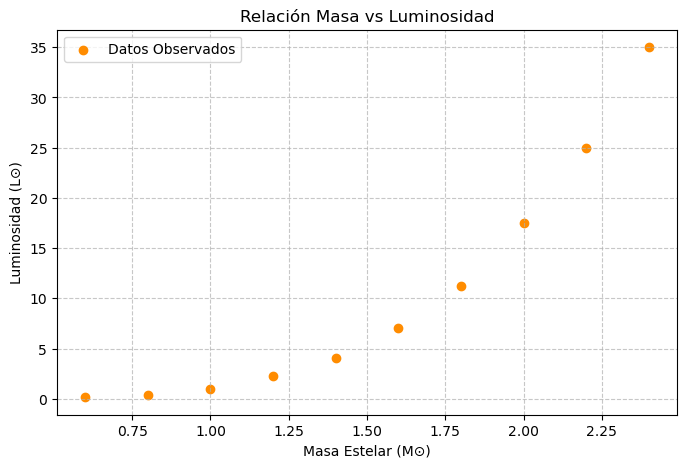

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset proporcionado (Hard-coded)
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

# Visualización inicial
plt.figure(figsize=(8, 5))
plt.scatter(M, L, color='darkorange', label='Datos Observados')
plt.xlabel('Masa Estelar (M⊙)')
plt.ylabel('Luminosidad (L⊙)')
plt.title('Relación Masa vs Luminosidad')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Comentario sobre linealidad: 
# Observamos que la relación no es perfectamente lineal; parece tener una 
# curvatura acelerada, lo que sugiere que un modelo lineal será una aproximación limitada.

Comentario sobre linealidad: Al observar la gráfica, los datos muestran una curvatura ascendente. Aunque una línea recta puede aproximar el comportamiento, la relación real parece ser no lineal (ley de potencia), lo que indica limitaciones inherentes para un modelo de regresión lineal simple.

3. Modelo y Función de Pérdida
Definimos nuestra hipótesis como f 
w,b
​
 (M)=w⋅M+b. Para medir qué tan bien se ajustan nuestros parámetros w (peso) y b (sesgo), implementamos la función de Error Cuadrático Medio (MSE).

In [2]:
def predict(M, w, b):
    """Calcula la predicción L_hat = w*M + b"""
    return w * M + b

def compute_cost(M, L, w, b):
    """Calcula el costo J(w,b) utilizando Mean Squared Error"""
    n = len(L)
    predictions = predict(M, w, b)
    cost = (1 / (2 * n)) * np.sum((predictions - L)**2)
    return cost

4. Visualización de la Superficie de Costo (Mandatorio)
Para entender la optimización, evaluamos J(w,b) en una rejilla de valores. El mínimo de esta superficie representa los parámetros óptimos donde el error es el más bajo posible.

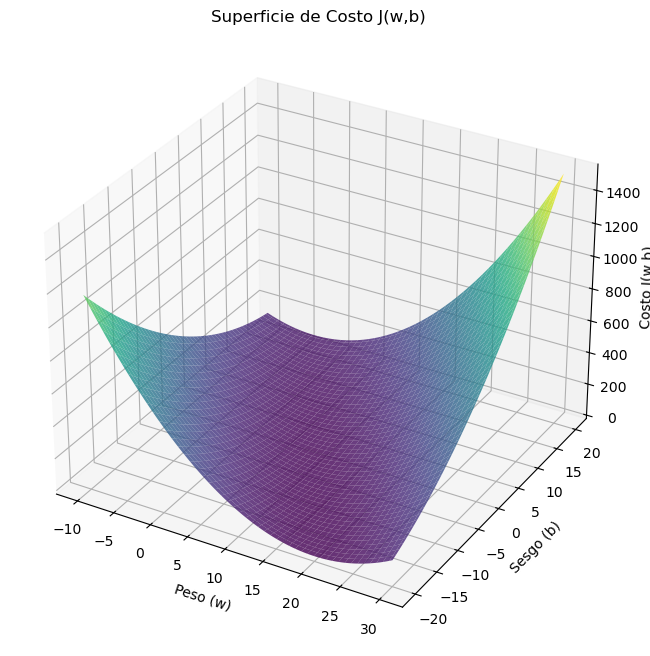

In [3]:
# Creación de la rejilla (Grid)
w_range = np.linspace(-10, 30, 100)
b_range = np.linspace(-20, 20, 100)
W, B = np.meshgrid(w_range, b_range)
zs = np.array([compute_cost(M, L, w, b) for w, b in zip(np.ravel(W), np.ravel(B))])
Z = zs.reshape(W.shape)

# Graficar superficie 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('Peso (w)')
ax.set_ylabel('Sesgo (b)')
ax.set_zlabel('Costo J(w,b)')
plt.title('Superficie de Costo J(w,b)')
plt.show()

Al igual que los ejemplos desarrollados en clase podemos evidenciar que para la grafica de costo tenemos un plano con curvatura con un minimo absoluto visible 

5. Gradientes y Optimización
Para minimizar el costo, necesitamos las derivadas parciales de J(w,b) respecto a w y b. Implementaremos dos versiones: una con ciclos explícitos y otra vectorizada para demostrar la eficiencia computacional.

        5.1 Gradiente Descendente (No Vectorizado)

In [4]:
def compute_gradients_loop(M, L, w, b):
    n = len(L)
    dj_dw = 0
    dj_db = 0
    for i in range(n):
        prediction_i = w * M[i] + b
        error_i = prediction_i - L[i]
        dj_dw += error_i * M[i]
        dj_db += error_i
    return dj_dw / n, dj_db / n

        5.2 Gradiente Descendente (Vectorizado)

In [5]:
def compute_gradients_vectorized(M, L, w, b):
    n = len(L)
    errors = predict(M, w, b) - L
    dj_dw = (1/n) * np.dot(errors, M)
    dj_db = (1/n) * np.sum(errors)
    return dj_dw, dj_db

6. Entrenamiento y Convergencia
Ejecutamos el algoritmo de Gradiente Descendente. Es crucial monitorear la curva de pérdida para asegurar que el modelo está convergiendo correctamente.

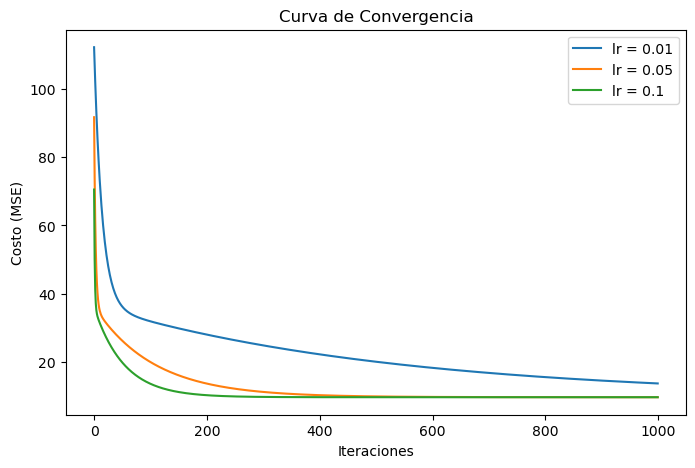

In [6]:
def gradient_descent(M, L, w_init, b_init, lr, iterations):
    w, b = w_init, b_init
    cost_history = []
    
    for i in range(iterations):
        dw, db = compute_gradients_vectorized(M, L, w, b)
        w -= lr * dw
        b -= lr * db
        cost_history.append(compute_cost(M, L, w, b))
        
    return w, b, cost_history

# Experimentos con diferentes Learning Rates
learning_rates = [0.01, 0.05, 0.1]
plt.figure(figsize=(8, 5))

for lr in learning_rates:
    _, _, history = gradient_descent(M, L, 0, 0, lr, 1000)
    plt.plot(history, label=f'lr = {lr}')

plt.xlabel('Iteraciones')
plt.ylabel('Costo (MSE)')
plt.title('Curva de Convergencia')
plt.legend()
plt.show()

7. Resultados Finales y Ajuste del Modelo
Finalmente, visualizamos la línea de regresión obtenida sobre nuestros datos originales y discutimos los errores sistemáticos.

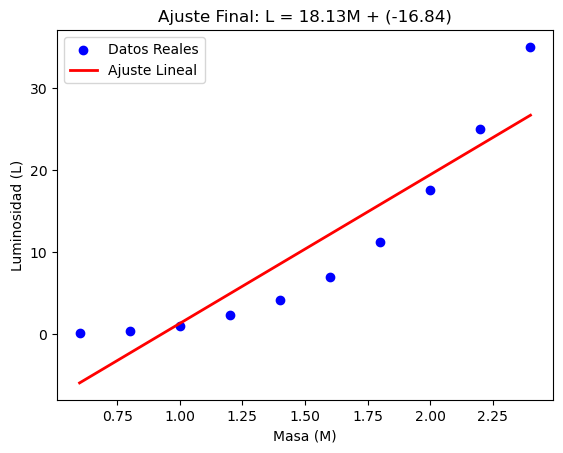

Parámetros finales: w = 18.1303, b = -16.8354


In [7]:
# Entrenamiento final con el mejor LR
w_final, b_final, _ = gradient_descent(M, L, 0, 0, 0.1, 1500)

plt.scatter(M, L, color='blue', label='Datos Reales')
plt.plot(M, predict(M, w_final, b_final), color='red', linewidth=2, label='Ajuste Lineal')
plt.xlabel('Masa (M)')
plt.ylabel('Luminosidad (L)')
plt.title(f'Ajuste Final: L = {w_final:.2f}M + ({b_final:.2f})')
plt.legend()
plt.show()

print(f"Parámetros finales: w = {w_final:.4f}, b = {b_final:.4f}")

8. Preguntas Conceptuales
¿Cuál es el significado astrofísico de w? Representa la tasa de incremento de la luminosidad en relación con la masa solar. En términos físicos simples, indica cuánta energía extra emite una estrella por cada unidad de masa adicional.

    ¿Por qué un modelo lineal es limitado aquí? La física estelar (relación Masa-Luminosidad) sigue una función de potencia L∝M 
k
 . Un modelo lineal no puede capturar la aceleración del crecimiento de la luminosidad en estrellas de mayor masa, lo que resulta en un ajuste pobre en los extremos del dataset.